## CRISP-DM: Data Understanding and Data Preparation

In this task, the dataset was explored to understand its structure, data types, missing values, and possible issues. After understanding the data, preprocessing steps were applied, including handling missing values, feature engineering, encoding categorical variables, and scaling numerical features. These steps prepare the dataset for classification, regression, and clustering tasks.


#Task 1 - Data Preprocessing


# Business Understanding

The hotel management company aims to reduce booking cancellations, forecast revenue, and improve customer satisfaction using historical booking data.

The main objectives are:

- Predict booking cancellations
- Forecast hotel revenue
- Segment customers for marketing and loyalty programs
- Support data-driven decision making

# Data Understanding

The Hotel Booking Demand dataset contains historical hotel booking records, including customer information, booking details, room types, market segments, and pricing information.

The dataset consists of 119,390 records and 32 attributes containing both numerical and categorical features.

In [3]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [4]:
# Load dataset

df=pd.read_csv("hotel_bookings.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


## 1. Data Understanding

The hotel booking dataset was studied to understand tis structure, data types, missing values and its overall characteristrics before preprocessing.

In [5]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(119390, 32)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [7]:
print(df.isnull().sum())

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

# Data Preparation

The dataset was prepared by handling missing values, encoding categorical variables, scaling numerical features, and creating new features that improve model performance.

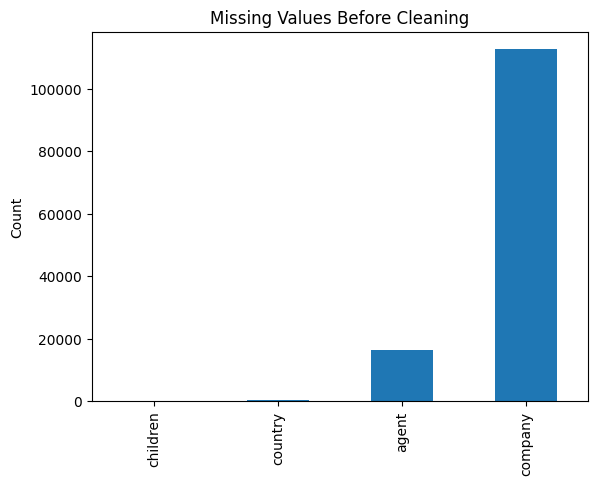

In [8]:
import matplotlib.pyplot as plt
missing_values = df.isnull().sum()
missing_values[missing_values > 0].plot(
    kind="bar"
)

plt.title("Missing Values Before Cleaning")
plt.ylabel("Count")
plt.show()

## 2. Data Cleaning and Missing value Handling

Missing values were inspected in the dataset.Missing values were identified in children, country, agent and company columns. Necessary steps were apploed to make sure data quality before machine learnign modelling

In [9]:
#Handling missing values

df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")
df["agent"] = df["agent"].fillna(0)
df["company"] = df["company"].fillna(0)

print(df.isnull().sum())

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

## Mising Value Handling

Dataset contained missing values in children, country, agent and company columns.

1.Missing values in `children` were replaced with 0 because missing values likely mean no children were included in the booking. Missing values in `country` were replaced with "Unknown" because removing these rows could reduce useful booking data. Missing values in `agent` and `company` were replaced with 0 because missing values likely indicate that no agent or company was involved in the booking.

## 3.Feature Engineering

Feature engineering was done to create additional variabls which provide more meaningful information for learning models.New features like the total guests, total nights, season, total revenue, weekend ratio, and to lead time category was created.

In [10]:
# Total guests
df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df[["adults","children","babies","total_guests"]].head()



,adults,children,babies,total_guests
0,2,0.0,0,2.0
1,2,0.0,0,2.0
2,1,0.0,0,1.0
3,1,0.0,0,1.0
4,2,0.0,0,2.0


New features were created to make the dataset more meaningful for hotel decision-making. `total_guests` shows the number of people in each booking, `total_nights` shows the length of stay, and `total_revenue` estimates the booking value. Seasonal and lead time categories help identify booking patterns over time.

In [11]:
df["total_nights"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

df[["stays_in_weekend_nights",
    "stays_in_week_nights",
    "total_nights"]].head()

,stays_in_weekend_nights,stays_in_week_nights,total_nights
0,0,0,0
1,0,0,0
2,0,1,1
3,0,1,1
4,0,2,2


In [12]:
#Total revenue
df["total_revenue"] = df["adr"] * df["total_nights"]
df[["adr","total_nights","total_revenue"]].head()

,adr,total_nights,total_revenue
0,0.0,0,0.0
1,0.0,0,0.0
2,75.0,1,75.0
3,75.0,1,75.0
4,98.0,2,196.0


In [13]:
print(df[["total_guests",
          "total_nights",
          "total_revenue"]].head())

   total_guests  total_nights  total_revenue
0           2.0             0            0.0
1           2.0             0            0.0
2           1.0             1           75.0
3           1.0             1           75.0
4           2.0             2          196.0


In [14]:
#Create season feature

def get_season(month):
  if month in ["December", "January", "February"]:
    return "Winter"
  elif month in ["March", "April", "May"]:
    return "Spring"
  elif month in ["June", "July", "August"]:
    return "Summer"
  else:
    return "Autumn"

df["season"] = df["arrival_date_month"].apply(get_season)
print(df[["arrival_date_month","season"]].head())

  arrival_date_month  season
0               July  Summer
1               July  Summer
2               July  Summer
3               July  Summer
4               July  Summer


In [15]:
# Weekend ratio

df["weekend_ratio"] = (
    df["stays_in_weekend_nights"] /
    (df["total_nights"] + 1)
)
print(df[["weekend_ratio"]].head())

   weekend_ratio
0            0.0
1            0.0
2            0.0
3            0.0
4            0.0


In [16]:
# Lead time category

def lead_category(x):
  if x <= 30:
    return "Short"
  elif x <= 90:
    return "Medium"
  else:
    return "Long"

df["lead_time_category"] = df["lead_time"].apply(lead_category)

print(df[["lead_time",
          "lead_time_category"]].head())


   lead_time lead_time_category
0        342               Long
1        737               Long
2          7              Short
3         13              Short
4         14              Short


In [17]:
print(df.columns)

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'total_guests',
       'total_nights', 'total_revenue', 'season', 'weekend_ratio',
       'lead_time_category'],
      dtype='object')


### Outlier Analysis

Outliers were reviewed using descriptive statistics. Since the dataset represents real hotel booking behaviour, extreme values were retained because they may represent genuine customer booking patterns and could provide useful information for model training.

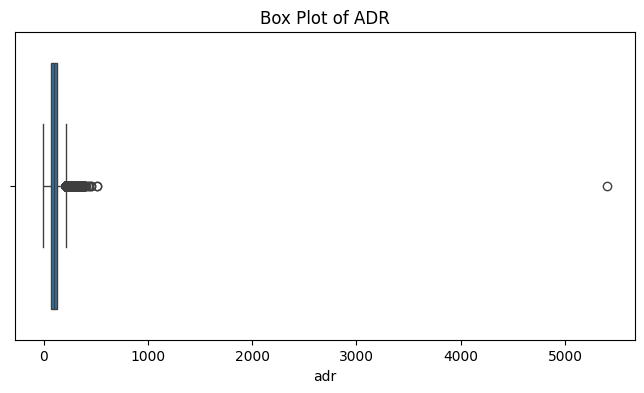

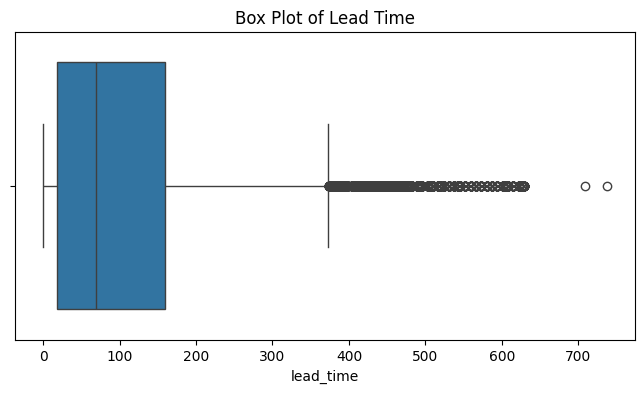

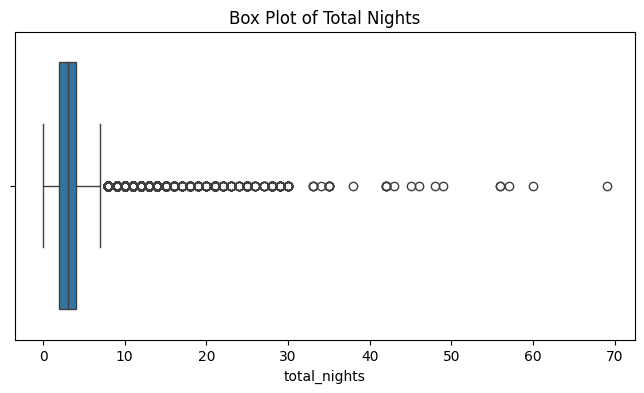

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.boxplot(x=df["adr"])
plt.title("Box Plot of ADR")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df["lead_time"])
plt.title("Box Plot of Lead Time")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df["total_nights"])
plt.title("Box Plot of Total Nights")
plt.show()

### Outlier Interpretation
The box plots show the presence of several outliers in ADR, lead time, and total nights. These extreme values may represent unusual booking behaviour rather than data entry errors. Therefore, the outliers were retained to preserve valuable business information while scaling was applied to reduce their impact on machine learning models.

## 4. Encoding Categorical Variables

Categorical variables cannot be directly processed by machine learning algorithms.

Label Encoding was applied to transform categorical features such as hotel, meal, market_segment, distribution_channel, reserved_room_type, assigned_room_type, customer_type, season, and lead_time_category into numerical values suitable for machine learning models.

In [19]:
# Check categorical columns

categorical_columns =df.select_dtypes(include=["object"]).columns
print(categorical_columns)

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date', 'season', 'lead_time_category'],
      dtype='object')


Label Encoding was used to convert categorical variables into numerical values for machine learning models. However, a limitation is that Label Encoding may create artificial order between categories. For example, one market segment may receive a higher number than another even though there is no real ranking. In future improvement, One-Hot Encoding could be used for non-ordinal categorical variables such as hotel, meal, market_segment, and customer_type.

In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

print(df.head())

   hotel  is_canceled  lead_time  arrival_date_year  arrival_date_month  \
0      1            0        342               2015                   5   
1      1            0        737               2015                   5   
2      1            0          7               2015                   5   
3      1            0         13               2015                   5   
4      1            0         14               2015                   5   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  \
0                        0                     0       2  ...   
1                        0                     0       2  ...   
2    

### Removing Data Leakage Columns

The columns reservation_status and reservation_status_date were removed because they contain information about the final booking outcome. Keeping these columns could cause data leakage and produce unrealistic model performance.

In [21]:
df = df.drop(["reservation_status", "reservation_status_date"], axis=1)
print(df.shape)

(119390, 36)


## 5. Feature Scaling

Machine learning algorithms often perform better when numerical features are on a similar scale.

StandardScaler was applied to numerical features such as lead_time, adr, total_guests, total_nights, previous_cancellations, and total_of_special_requests.

This transformation standardizes the data with a mean of 0 and a standard deviation of 1, improving model performance and convergence.

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_columns = [
    "lead_time",
    "adults",
    "children",
    "babies",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adr",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "total_of_special_requests",
    "total_guests",
    "total_nights",
    "total_revenue",
    "weekend_ratio"
]

df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

print(df[numeric_columns].head())

   lead_time    adults  children    babies  stays_in_weekend_nights  \
0   2.227051  0.247897 -0.260659 -0.081579                 -0.92889   
1   5.923385  0.247897 -0.260659 -0.081579                 -0.92889   
2  -0.907814 -1.478447 -0.260659 -0.081579                 -0.92889   
3  -0.851667 -1.478447 -0.260659 -0.081579                 -0.92889   
4  -0.842309  0.247897 -0.260659 -0.081579                 -0.92889   

   stays_in_week_nights       adr  previous_cancellations  \
0             -1.310240 -2.015038                -0.10318   
1             -1.310240 -2.015038                -0.10318   
2             -0.786207 -0.530935                -0.10318   
3             -0.786207 -0.530935                -0.10318   
4             -0.262174 -0.075810                -0.10318   

   previous_bookings_not_canceled  total_of_special_requests  total_guests  \
0                       -0.091555                  -0.720694      0.043967   
1                       -0.091555                 

Numerical features were scaled using StandardScaler to ensure that features with larger values did not dominate the machine learning models. In a more advanced workflow, the scaler should be fitted only on the training data and then applied to the test data to avoid data leakage.

##Outlier Explanation

Some numerical columns such as `lead_time`, `adr`, and `total_nights` may contain outliers. These values were retained because they can represent real hotel booking situations, such as very early bookings or long stays. Removing them without strong justification could remove useful business information.

## 6. Train-Test Split

The data was divided into training and testing sets to prepare for the machine learning models development.

In [23]:
from sklearn.model_selection import train_test_split

X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set Shape", X_train.shape)
print("Testing Set Shape", X_test.shape)

Training Set Shape (95512, 35)
Testing Set Shape (23878, 35)


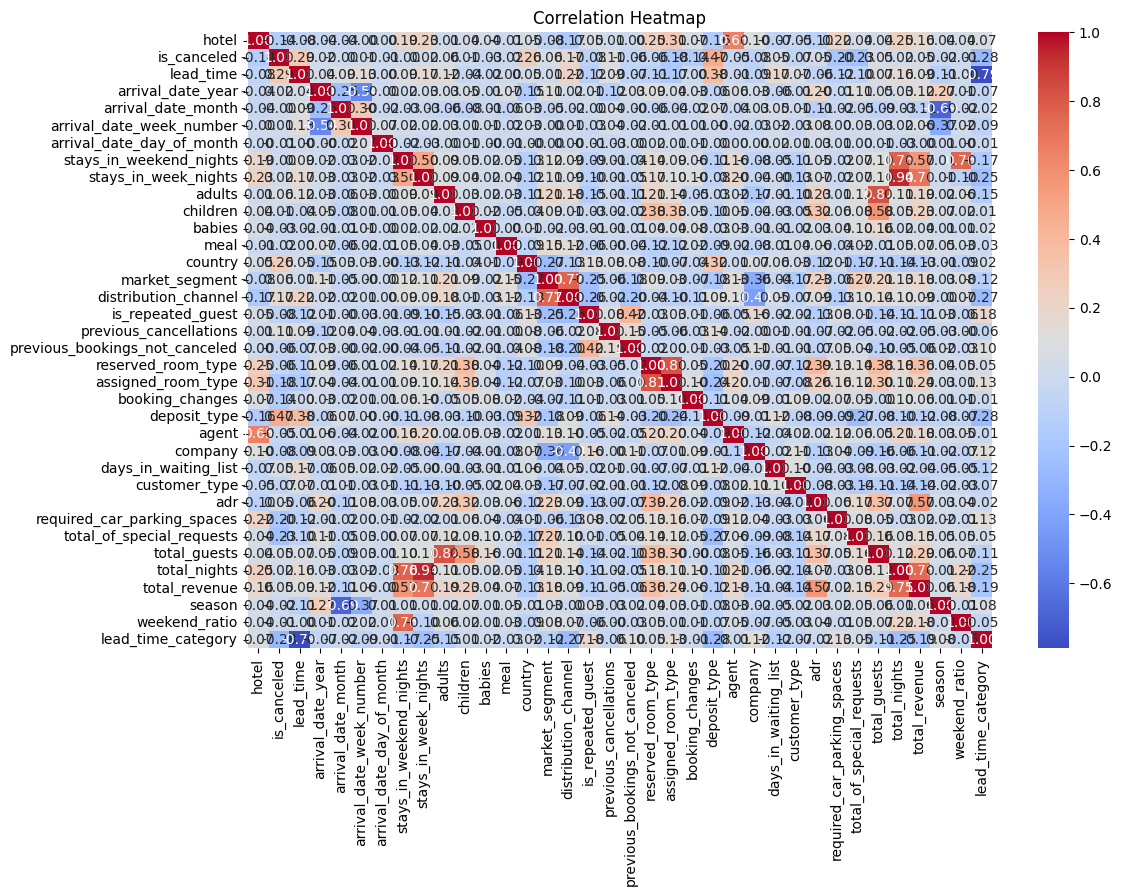

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Heatmap Interpretation

# The correlation heatmap shows the relationships between numerical variables in the dataset. Values closer to 1 indicate strong positive correlations, values closer to -1 indicate strong negative correlations, and values near 0 indicate weak relationships. This visualization helps identify patterns that may influence booking cancellations, revenue, and customer behaviour.

In [25]:
# Save the cleaned dataset

df.to_csv("hotel_bookings_cleaned.csv", index=False)
print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


In [26]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 32252


### Duplicate Records

A duplicate check identified 32,252 duplicate records in the dataset.

These records were retained because repeated booking patterns can occur naturally in hotel reservation systems and do not necessarily represent data entry errors. Removing them could eliminate genuine customer booking behaviour and reduce the representativeness of the dataset.

Therefore, the original records were preserved to maintain dataset consistency throughout the modelling process.

### Limitation

Some categorical variables were encoded using Label Encoding. Although this allows machine learning models to process categorical data, it may introduce an artificial order between categories. One-Hot Encoding could be considered in future work for non-ordinal features.